In [1]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Read the datasets

app = pd.read_csv("../dataset/application_record.csv")
credit = pd.read_csv("../dataset/credit_record.csv")

print("Application Dataset Shape:", app.shape)
print("Credit Dataset Shape:", credit.shape)

Application Dataset Shape: (438557, 18)
Credit Dataset Shape: (1048575, 3)


In [3]:
# Display first 5 rows of Application Dataset

app.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [4]:
# Display first 5 rows of Credit Dataset

credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [5]:
app.info()

<class 'pandas.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  str    
 2   FLAG_OWN_CAR         438557 non-null  str    
 3   FLAG_OWN_REALTY      438557 non-null  str    
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  str    
 7   NAME_EDUCATION_TYPE  438557 non-null  str    
 8   NAME_FAMILY_STATUS   438557 non-null  str    
 9   NAME_HOUSING_TYPE    438557 non-null  str    
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL           438557 

In [6]:
credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype
---  ------          --------------    -----
 0   ID              1048575 non-null  int64
 1   MONTHS_BALANCE  1048575 non-null  int64
 2   STATUS          1048575 non-null  str  
dtypes: int64(2), str(1)
memory usage: 24.0 MB


In [7]:
app.columns

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS'],
      dtype='str')

In [8]:
app["OCCUPATION_TYPE"].value_counts()

OCCUPATION_TYPE
Laborers                 78240
Core staff               43007
Sales staff              41098
Managers                 35487
Drivers                  26090
High skill tech staff    17289
Accountants              15985
Medicine staff           13520
Cooking staff             8076
Security staff            7993
Cleaning staff            5845
Private service staff     3456
Low-skill Laborers        2140
Secretaries               2044
Waiters/barmen staff      1665
Realty agents             1041
HR staff                   774
IT staff                   604
Name: count, dtype: int64

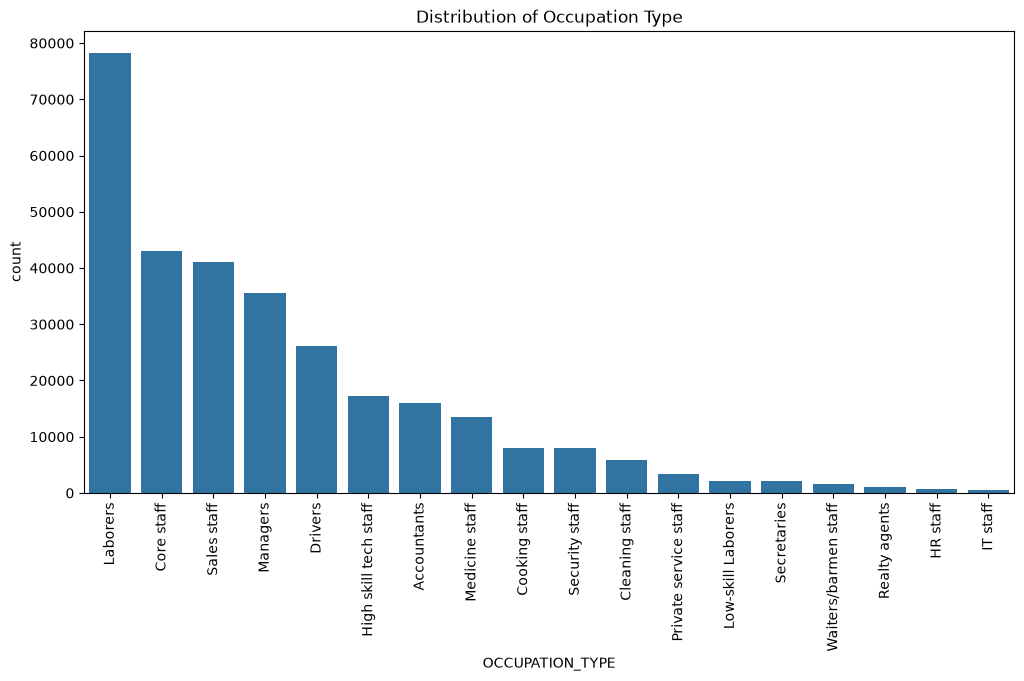

In [9]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=app,
    x="OCCUPATION_TYPE",
    order=app["OCCUPATION_TYPE"].value_counts().index
)

plt.xticks(rotation=90)
plt.title("Distribution of Occupation Type")
plt.show()


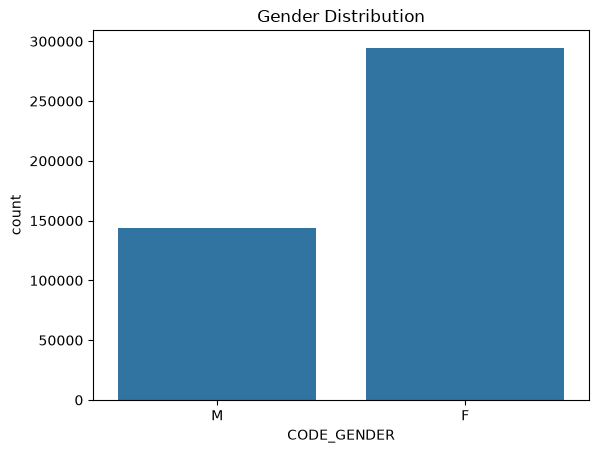

In [10]:
app["CODE_GENDER"].value_counts()
sns.countplot(data=app, x="CODE_GENDER")
plt.title("Gender Distribution")
plt.show()

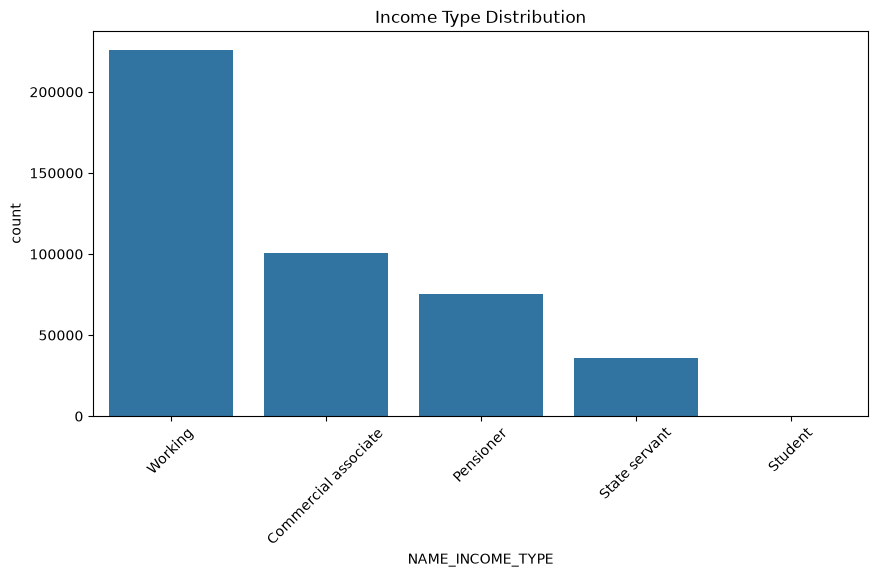

In [11]:
app["NAME_INCOME_TYPE"].value_counts()
plt.figure(figsize=(10,5))

sns.countplot(
    data=app,
    x="NAME_INCOME_TYPE",
    order=app["NAME_INCOME_TYPE"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Income Type Distribution")
plt.show()

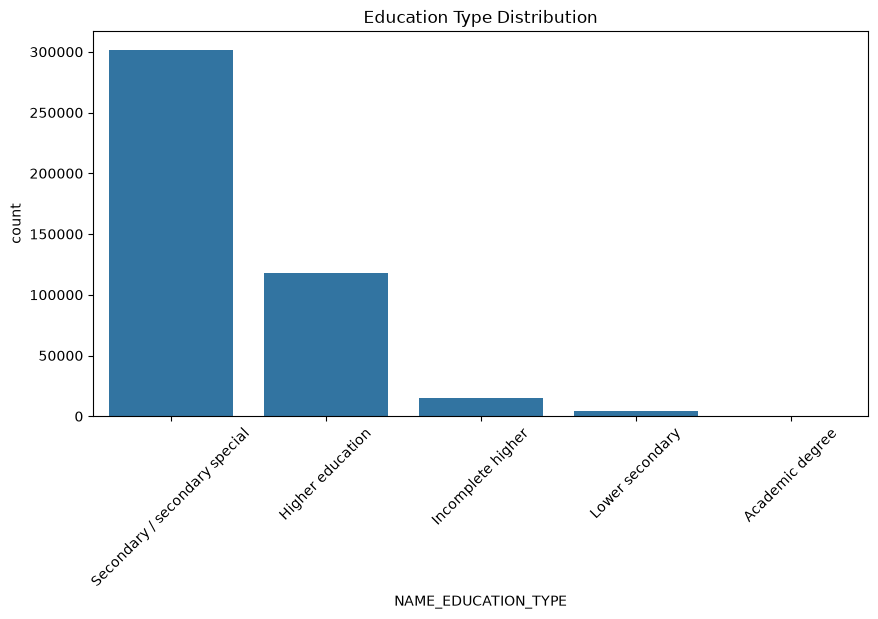

In [12]:
app["NAME_EDUCATION_TYPE"].value_counts()
plt.figure(figsize=(10,5))

sns.countplot(
    data=app,
    x="NAME_EDUCATION_TYPE",
    order=app["NAME_EDUCATION_TYPE"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Education Type Distribution")
plt.show()

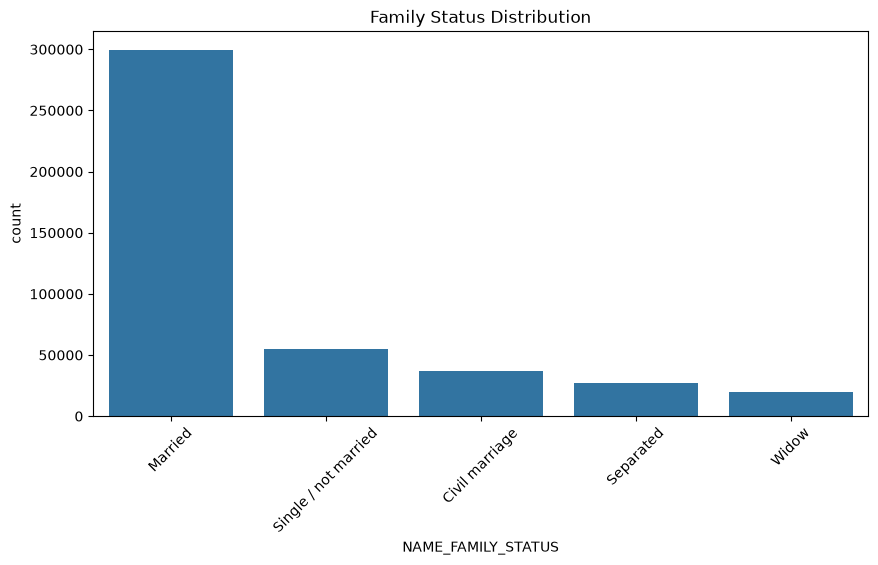

In [13]:
app["NAME_FAMILY_STATUS"].value_counts()
plt.figure(figsize=(10,5))

sns.countplot(
    data=app,
    x="NAME_FAMILY_STATUS",
    order=app["NAME_FAMILY_STATUS"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Family Status Distribution")
plt.show()

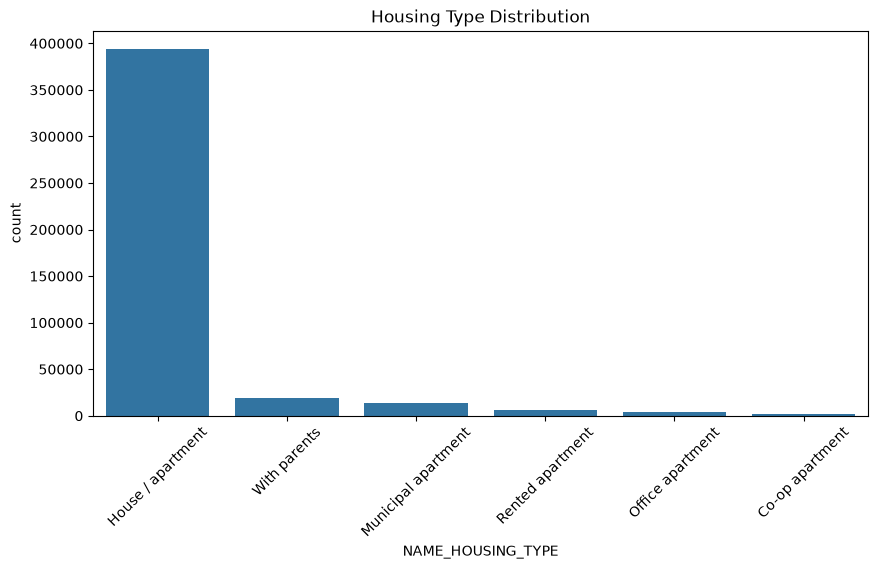

In [14]:
app["NAME_HOUSING_TYPE"].value_counts()
plt.figure(figsize=(10,5))

sns.countplot(
    data=app,
    x="NAME_HOUSING_TYPE",
    order=app["NAME_HOUSING_TYPE"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Housing Type Distribution")
plt.show()

In [15]:
# Select only numerical columns
numerical_data = app.select_dtypes(include=['int64', 'float64'])

numerical_data.head()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
0,5008804,0,427500.0,-12005,-4542,1,1,0,0,2.0
1,5008805,0,427500.0,-12005,-4542,1,1,0,0,2.0
2,5008806,0,112500.0,-21474,-1134,1,0,0,0,2.0
3,5008808,0,270000.0,-19110,-3051,1,0,1,1,1.0
4,5008809,0,270000.0,-19110,-3051,1,0,1,1,1.0


In [16]:
# Correlation Matrix
corr = numerical_data.corr()

corr

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
ID,1.000000,-0.005178,0.011179,-0.004994,-0.002467,NaN,-0.023319,-0.018992,0.032875,-0.001862
CNT_CHILDREN,-0.005178,1.000000,0.019177,0.349088,-0.241535,NaN,0.038418,-0.038266,0.028457,0.884781
AMT_INCOME_TOTAL,0.011179,0.019177,1.000000,0.053775,-0.141291,NaN,-0.033635,0.004444,0.112139,0.011454
DAYS_BIRTH,-0.004994,0.349088,0.053775,1.000000,-0.617908,NaN,0.171829,-0.037984,0.096752,0.306179
DAYS_EMPLOYED,-0.002467,-0.241535,-0.141291,-0.617908,1.000000,NaN,-0.232208,0.004868,-0.074372,-0.234373
FLAG_MOBIL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_WORK_PHONE,-0.023319,0.038418,-0.033635,0.171829,-0.232208,NaN,1.000000,0.290066,-0.060915,0.049777
FLAG_PHONE,-0.018992,-0.038266,0.004444,-0.037984,0.004868,NaN,0.290066,1.000000,-0.001170,-0.024213
FLAG_EMAIL,0.032875,0.028457,0.112139,0.096752,-0.074372,NaN,-0.060915,-0.001170,1.000000,0.022054
CNT_FAM_MEMBERS,-0.001862,0.884781,0.011454,0.306179,-0.234373,NaN,0.049777,-0.024213,0.022054,1.000000


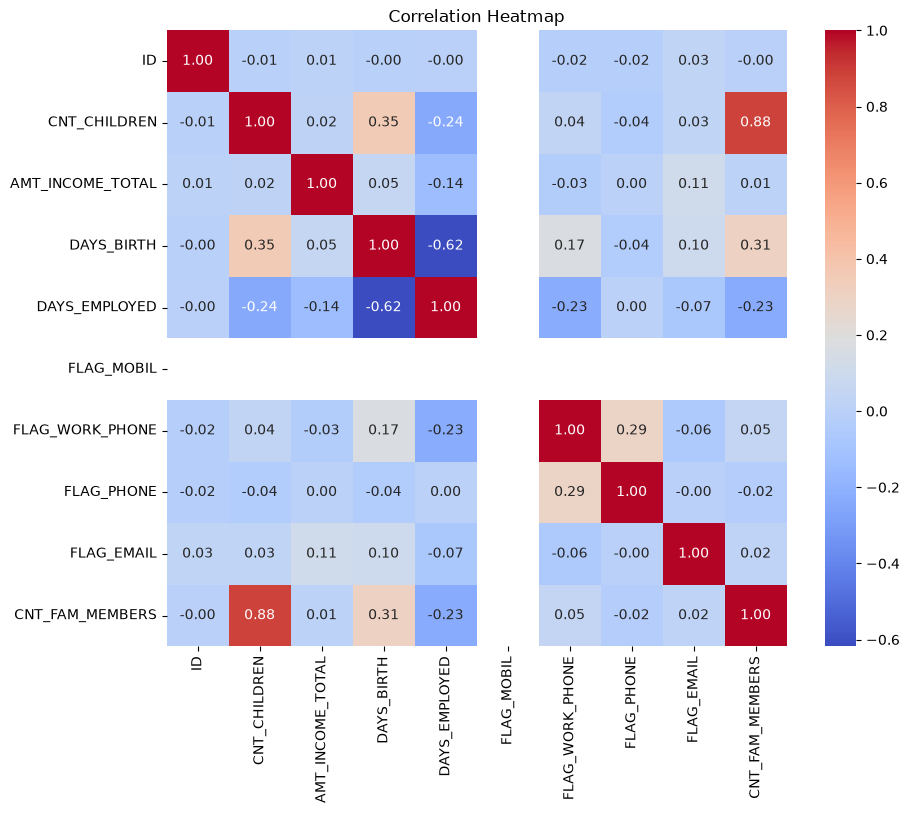

In [17]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [18]:
# Descriptive Statistics of the Application Dataset
app.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


In [19]:
credit.describe()

,ID,MONTHS_BALANCE
count,1.048575e+06,1.048575e+06
mean,5.068286e+06,-1.913700e+01
std,4.615058e+04,1.402350e+01
min,5.001711e+06,-6.000000e+01
25%,5.023644e+06,-2.900000e+01
50%,5.062104e+06,-1.700000e+01
75%,5.113856e+06,-7.000000e+00
max,5.150487e+06,0.000000e+00


In [20]:
# Check duplicate rows
print("Duplicate rows in Application Dataset:", app.duplicated().sum())
print("Duplicate rows in Credit Dataset:", credit.duplicated().sum())

Duplicate rows in Application Dataset: 0
Duplicate rows in Credit Dataset: 0


In [21]:
# Remove duplicate rows
app = app.drop_duplicates()
credit = credit.drop_duplicates()

print("Duplicate rows removed successfully!")

Duplicate rows removed successfully!


In [22]:
# Verify duplicates are removed
print("Duplicate rows in Application Dataset:", app.duplicated().sum())
print("Duplicate rows in Credit Dataset:", credit.duplicated().sum())

Duplicate rows in Application Dataset: 0
Duplicate rows in Credit Dataset: 0


In [23]:
# Remove duplicate applicant IDs
app = app.drop_duplicates(subset="ID", keep="first")

In [24]:
type(app)

pandas.DataFrame

In [25]:
import pandas as pd

app = pd.read_csv("../dataset/application_record.csv")
credit = pd.read_csv("../dataset/credit_record.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [26]:
type(app)

pandas.DataFrame

In [27]:
print("Missing Values in Application Dataset:")
print(app.isnull().sum())

print("\nMissing Values in Credit Dataset:")
print(credit.isnull().sum())

Missing Values in Application Dataset:
ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

Missing Values in Credit Dataset:
ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64


In [28]:
# Create a backup of the original dataset
app_clean = app.copy()
credit_clean = credit.copy()

In [29]:
# Create a new feature
app_clean["TOTAL_FAMILY_MEMBERS"] = (
    app_clean["CNT_FAM_MEMBERS"] + app_clean["CNT_CHILDREN"]
)

app_clean[["CNT_FAM_MEMBERS", "CNT_CHILDREN", "TOTAL_FAMILY_MEMBERS"]].head()

,CNT_FAM_MEMBERS,CNT_CHILDREN,TOTAL_FAMILY_MEMBERS
0,2.0,0,2.0
1,2.0,0,2.0
2,2.0,0,2.0
3,1.0,0,1.0
4,1.0,0,1.0


In [30]:
# Remove unnecessary column
app_clean.drop(columns=["FLAG_MOBIL"], inplace=True)

print("FLAG_MOBIL removed successfully.")

FLAG_MOBIL removed successfully.


In [31]:
# Convert negative values to positive
app_clean["DAYS_BIRTH"] = app_clean["DAYS_BIRTH"].abs()
app_clean["DAYS_EMPLOYED"] = app_clean["DAYS_EMPLOYED"].abs()

app_clean[["DAYS_BIRTH", "DAYS_EMPLOYED"]].head()

,DAYS_BIRTH,DAYS_EMPLOYED
0,12005,4542
1,12005,4542
2,21474,1134
3,19110,3051
4,19110,3051


In [32]:
import pandas as pd

app = pd.read_csv("../dataset/application_record.csv")
credit = pd.read_csv("../dataset/credit_record.csv")

In [33]:
app_clean = app.copy()
credit_clean = credit.copy()

In [34]:
print(app_clean.head())

        ID CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  CNT_CHILDREN  \
0  5008804           M            Y               Y             0   
1  5008805           M            Y               Y             0   
2  5008806           M            Y               Y             0   
3  5008808           F            N               Y             0   
4  5008809           F            N               Y             0   

   AMT_INCOME_TOTAL      NAME_INCOME_TYPE            NAME_EDUCATION_TYPE  \
0          427500.0               Working               Higher education   
1          427500.0               Working               Higher education   
2          112500.0               Working  Secondary / secondary special   
3          270000.0  Commercial associate  Secondary / secondary special   
4          270000.0  Commercial associate  Secondary / secondary special   

     NAME_FAMILY_STATUS  NAME_HOUSING_TYPE  DAYS_BIRTH  DAYS_EMPLOYED  \
0        Civil marriage   Rented apartment      -12005 

In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Fill missing occupation values
app_clean["OCCUPATION_TYPE"] = app_clean["OCCUPATION_TYPE"].fillna("Unknown")

categorical_columns = [
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE"
]

for col in categorical_columns:
    app_clean[col] = le.fit_transform(app_clean[col])

print("Categorical columns encoded successfully!")

Categorical columns encoded successfully!


In [36]:
credit_summary = credit_clean.groupby("ID").agg(
    open_month=("MONTHS_BALANCE", "min"),
    end_month=("MONTHS_BALANCE", "max")
)

credit_summary["window"] = (
    credit_summary["end_month"] - credit_summary["open_month"]
)

In [37]:
# Convert STATUS into binary target

def convert_status(status):
    if status in ["C", "X", "0"]:
        return 1      # Approved
    else:
        return 0      # Rejected

credit_clean["TARGET"] = credit_clean["STATUS"].apply(convert_status)

In [38]:
credit_target = credit_clean.groupby("ID")["TARGET"].min().reset_index()

credit_target.head()

,ID,TARGET
0,5001711,1
1,5001712,1
2,5001713,1
3,5001714,1
4,5001715,1


In [39]:
final_data = app_clean.merge(
    credit_summary,
    on="ID",
    how="left"
)

final_data = final_data.merge(
    credit_target,
    on="ID",
    how="left"
)

print(final_data.head())

        ID  CODE_GENDER  FLAG_OWN_CAR  FLAG_OWN_REALTY  CNT_CHILDREN  \
0  5008804            1             1                1             0   
1  5008805            1             1                1             0   
2  5008806            1             1                1             0   
3  5008808            0             0                1             0   
4  5008809            0             0                1             0   

   AMT_INCOME_TOTAL  NAME_INCOME_TYPE  NAME_EDUCATION_TYPE  \
0          427500.0                 4                    1   
1          427500.0                 4                    1   
2          112500.0                 4                    4   
3          270000.0                 0                    4   
4          270000.0                 0                    4   

   NAME_FAMILY_STATUS  NAME_HOUSING_TYPE  ...  FLAG_MOBIL  FLAG_WORK_PHONE  \
0                   0                  4  ...           1                1   
1                   0                 

In [40]:
final_data = final_data.dropna(subset=["TARGET"])

print(final_data["TARGET"].isnull().sum())

0


In [41]:
X = final_data.drop(["ID", "TARGET"], axis=1)
y = final_data["TARGET"]

X = X.fillna(0)

print(X.shape)
print(y.shape)

(36457, 20)
(36457,)


In [42]:
print(X.select_dtypes(include="object").columns)

Index([], dtype='str')


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [44]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())

TARGET
0.0    25746
1.0    25746
Name: count, dtype: int64


In [45]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [46]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.19      0.30      0.23       872
         1.0       0.90      0.83      0.86      6420

    accuracy                           0.76      7292
   macro avg       0.54      0.56      0.55      7292
weighted avg       0.81      0.76      0.78      7292

[[ 264  608]
 [1120 5300]]
Accuracy: 0.7630279758639605


In [47]:
import joblib

joblib.dump(rf_model, "../model/model.pkl", compress=3)

['../model/model.pkl']

In [48]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))
print()

print("Classification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.7630279758639605

Confusion Matrix
[[ 264  608]
 [1120 5300]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.19      0.30      0.23       872
         1.0       0.90      0.83      0.86      6420

    accuracy                           0.76      7292
   macro avg       0.54      0.56      0.55      7292
weighted avg       0.81      0.76      0.78      7292



In [49]:
credit_summary = credit_clean.groupby("ID").agg(
    open_month=("MONTHS_BALANCE", "min"),
    end_month=("MONTHS_BALANCE", "max")
)

credit_summary["window"] = (
    credit_summary["end_month"] - credit_summary["open_month"]
)

credit_summary.head()

,open_month,end_month,window
ID,,,
5001711,-3,0,3
5001712,-18,0,18
5001713,-21,0,21
5001714,-14,0,14
5001715,-59,0,59


In [50]:
final_data = app_clean.merge(
    credit_summary,
    on="ID",
    how="left"
)

final_data.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,open_month,end_month,window
0,5008804,1,1,1,0,427500.0,4,1,0,4,...,-4542,1,1,0,0,17,2.0,-15.0,0.0,15.0
1,5008805,1,1,1,0,427500.0,4,1,0,4,...,-4542,1,1,0,0,17,2.0,-14.0,0.0,14.0
2,5008806,1,1,1,0,112500.0,4,4,1,1,...,-1134,1,0,0,0,16,2.0,-29.0,0.0,29.0
3,5008808,0,0,1,0,270000.0,0,4,3,1,...,-3051,1,0,1,1,14,1.0,-4.0,0.0,4.0
4,5008809,0,0,1,0,270000.0,0,4,3,1,...,-3051,1,0,1,1,14,1.0,-26.0,-22.0,4.0


In [51]:
# Save cleaned dataset
final_data.to_csv("../dataset/final_credit_approval.csv", index=False)

print("Final cleaned dataset saved successfully!")

Final cleaned dataset saved successfully!


In [52]:
print(credit["STATUS"].value_counts())

STATUS
C    442031
0    383120
X    209230
1     11090
5      1693
2       868
3       320
4       223
Name: count, dtype: int64


In [53]:
# Convert STATUS into binary target

def convert_status(status):
    if status in ["C", "X", "0"]:
        return 1      # Approved
    else:
        return 0      # Not Approved

credit["TARGET"] = credit["STATUS"].apply(convert_status)

credit[["STATUS", "TARGET"]].head()

,STATUS,TARGET
0,X,1
1,0,1
2,0,1
3,0,1
4,C,1


In [54]:
credit["TARGET"].value_counts()

TARGET
1    1034381
0      14194
Name: count, dtype: int64

In [55]:
credit_target = credit.groupby("ID")["TARGET"].min().reset_index()

credit_target.head()

,ID,TARGET
0,5001711,1
1,5001712,1
2,5001713,1
3,5001714,1
4,5001715,1


In [56]:
final_data = final_data.merge(
    credit_target,
    on="ID",
    how="left"
)

final_data.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,open_month,end_month,window,TARGET
0,5008804,1,1,1,0,427500.0,4,1,0,4,...,1,1,0,0,17,2.0,-15.0,0.0,15.0,0.0
1,5008805,1,1,1,0,427500.0,4,1,0,4,...,1,1,0,0,17,2.0,-14.0,0.0,14.0,0.0
2,5008806,1,1,1,0,112500.0,4,4,1,1,...,1,0,0,0,16,2.0,-29.0,0.0,29.0,1.0
3,5008808,0,0,1,0,270000.0,0,4,3,1,...,1,0,1,1,14,1.0,-4.0,0.0,4.0,1.0
4,5008809,0,0,1,0,270000.0,0,4,3,1,...,1,0,1,1,14,1.0,-26.0,-22.0,4.0,1.0


In [57]:
final_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  int64  
 2   FLAG_OWN_CAR         438557 non-null  int64  
 3   FLAG_OWN_REALTY      438557 non-null  int64  
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  int64  
 7   NAME_EDUCATION_TYPE  438557 non-null  int64  
 8   NAME_FAMILY_STATUS   438557 non-null  int64  
 9   NAME_HOUSING_TYPE    438557 non-null  int64  
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL           438557 

In [58]:
final_data.to_csv("../dataset/final_credit_approval.csv", index=False)

print("Final dataset saved successfully!")

Final dataset saved successfully!


In [59]:
final_data.columns

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'open_month',
       'end_month', 'window', 'TARGET'],
      dtype='str')

In [60]:
# Features (X) and Target (y)
X = final_data.drop("TARGET", axis=1)
y = final_data["TARGET"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (438557, 21)
y Shape: (438557,)


In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (350845, 21)
Testing Data: (87712, 21)


In [62]:
final_data["TARGET"].isnull().sum()

np.int64(402100)

In [63]:
final_data = final_data.dropna(subset=["TARGET"])

In [64]:
print(final_data["TARGET"].isnull().sum())

0


In [66]:
X = final_data.drop(["ID", "TARGET"], axis=1)
y = final_data["TARGET"]

In [67]:
print(X.isnull().sum().sum())

0


In [68]:
X = X.fillna(0)

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [70]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


C:\Users\CHINMAYI TEJA\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [71]:
y_pred = log_model.predict(X_test)

In [72]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8804168952276468


In [73]:

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[   0  872]
 [   0 6420]]


In [74]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [75]:
# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

In [76]:
# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [77]:
# Predict on test data
y_pred_rf = rf_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [78]:
def random_forest():
    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    rf_model.fit(X_train, y_train)

    y_pred = rf_model.predict(X_test)

    print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

random_forest()

Random Forest Accuracy: 0.8863137685134393

Confusion Matrix:
[[ 156  716]
 [ 113 6307]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.58      0.18      0.27       872
         1.0       0.90      0.98      0.94      6420

    accuracy                           0.89      7292
   macro avg       0.74      0.58      0.61      7292
weighted avg       0.86      0.89      0.86      7292



In [79]:
def d_tree():
    dt_model = DecisionTreeClassifier(random_state=42)

    dt_model.fit(X_train, y_train)

    y_pred = dt_model.predict(X_test)

    print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

d_tree()

Decision Tree Accuracy: 0.8370817334064728

Confusion Matrix:
[[ 343  529]
 [ 659 5761]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.34      0.39      0.37       872
         1.0       0.92      0.90      0.91      6420

    accuracy                           0.84      7292
   macro avg       0.63      0.65      0.64      7292
weighted avg       0.85      0.84      0.84      7292



In [80]:
import joblib

joblib.dump(rf_model, "../model/model.pkl")

['../model/model.pkl']

In [81]:
print(X.columns.tolist())

['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'open_month', 'end_month', 'window']


In [82]:
print(sorted(final_data["NAME_INCOME_TYPE"].unique()))
print(sorted(final_data["NAME_EDUCATION_TYPE"].unique()))
print(sorted(app["NAME_FAMILY_STATUS"].unique()))
print(sorted(app["NAME_HOUSING_TYPE"].unique()))

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
['Civil marriage', 'Married', 'Separated', 'Single / not married', 'Widow']
['Co-op apartment', 'House / apartment', 'Municipal apartment', 'Office apartment', 'Rented apartment', 'With parents']


In [83]:
import pandas as pd

In [84]:
import os
print(os.getcwd())

c:\Users\CHINMAYI TEJA\Documents\SmartBridge_CreditCardApprovalPrediction\notebooks


In [85]:
import pandas as pd

app = pd.read_csv("../dataset/application_record.csv")
credit = pd.read_csv("../dataset/credit_record.csv")

print(app.head())

        ID CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  CNT_CHILDREN  \
0  5008804           M            Y               Y             0   
1  5008805           M            Y               Y             0   
2  5008806           M            Y               Y             0   
3  5008808           F            N               Y             0   
4  5008809           F            N               Y             0   

   AMT_INCOME_TOTAL      NAME_INCOME_TYPE            NAME_EDUCATION_TYPE  \
0          427500.0               Working               Higher education   
1          427500.0               Working               Higher education   
2          112500.0               Working  Secondary / secondary special   
3          270000.0  Commercial associate  Secondary / secondary special   
4          270000.0  Commercial associate  Secondary / secondary special   

     NAME_FAMILY_STATUS  NAME_HOUSING_TYPE  DAYS_BIRTH  DAYS_EMPLOYED  \
0        Civil marriage   Rented apartment      -12005 

In [86]:
le_education = LabelEncoder()
le_education.fit(app["NAME_EDUCATION_TYPE"])

print(dict(zip(le_education.classes_, le_education.transform(le_education.classes_))))

{'Academic degree': np.int64(0), 'Higher education': np.int64(1), 'Incomplete higher': np.int64(2), 'Lower secondary': np.int64(3), 'Secondary / secondary special': np.int64(4)}


In [87]:
import joblib

model = joblib.load("../model/model.pkl")

print(model)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)


In [88]:
feature_names = X.columns.tolist()

feature_names

['CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'FLAG_MOBIL',
 'FLAG_WORK_PHONE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'open_month',
 'end_month',
 'window']

In [89]:
import pickle

with open("../model/features.pkl","wb") as f:
    pickle.dump(feature_names,f)

In [90]:
import os

print(os.getcwd())

c:\Users\CHINMAYI TEJA\Documents\SmartBridge_CreditCardApprovalPrediction\notebooks


In [91]:
import os

print(os.listdir())

['CreditCardApproval.ipynb']


In [92]:
import os

print(os.path.exists("../model/model.pkl"))

True


In [93]:
model = joblib.load("model.pkl")

FileNotFoundError: [Errno 2] No such file or directory: 'model.pkl'

In [94]:
model = joblib.load("model/model.pkl")

FileNotFoundError: [Errno 2] No such file or directory: 'model/model.pkl'

In [95]:
import os

print("Current folder:", os.getcwd())
print("Files/Folders:", os.listdir())

Current folder: c:\Users\CHINMAYI TEJA\Documents\SmartBridge_CreditCardApprovalPrediction\notebooks
Files/Folders: ['CreditCardApproval.ipynb']


In [96]:
from pathlib import Path

print("Current directory:", Path.cwd())
print("Parent model path:", (Path.cwd() / "../model").resolve())

Current directory: c:\Users\CHINMAYI TEJA\Documents\SmartBridge_CreditCardApprovalPrediction\notebooks
Parent model path: C:\Users\CHINMAYI TEJA\Documents\SmartBridge_CreditCardApprovalPrediction\model


In [100]:
from pathlib import Path
import joblib

project_root = Path.cwd().parent
model_dir = project_root / "model"

model_dir.mkdir(exist_ok=True)   # Creates the folder only if it doesn't exist

joblib.dump(rf_model, model_dir / "model.pkl")

print("Saved to:", model_dir / "model.pkl")

Saved to: c:\Users\CHINMAYI TEJA\Documents\SmartBridge_CreditCardApprovalPrediction\model\model.pkl


In [101]:
from pathlib import Path

root = Path.cwd().parent

print("Project root:", root)

for item in root.iterdir():
    print(item)

Project root: c:\Users\CHINMAYI TEJA\Documents\SmartBridge_CreditCardApprovalPrediction
c:\Users\CHINMAYI TEJA\Documents\SmartBridge_CreditCardApprovalPrediction\.git
c:\Users\CHINMAYI TEJA\Documents\SmartBridge_CreditCardApprovalPrediction\.venv
c:\Users\CHINMAYI TEJA\Documents\SmartBridge_CreditCardApprovalPrediction\app.py
c:\Users\CHINMAYI TEJA\Documents\SmartBridge_CreditCardApprovalPrediction\dataset
c:\Users\CHINMAYI TEJA\Documents\SmartBridge_CreditCardApprovalPrediction\model
c:\Users\CHINMAYI TEJA\Documents\SmartBridge_CreditCardApprovalPrediction\notebooks
c:\Users\CHINMAYI TEJA\Documents\SmartBridge_CreditCardApprovalPrediction\Procfile
c:\Users\CHINMAYI TEJA\Documents\SmartBridge_CreditCardApprovalPrediction\Project Documentation
c:\Users\CHINMAYI TEJA\Documents\SmartBridge_CreditCardApprovalPrediction\README.md
c:\Users\CHINMAYI TEJA\Documents\SmartBridge_CreditCardApprovalPrediction\requirements.txt
c:\Users\CHINMAYI TEJA\Documents\SmartBridge_CreditCardApprovalPredictio

In [102]:
from pathlib import Path
import joblib

save_path = Path.cwd().parent / "model" / "model.pkl"

print("Saving to:", save_path)

joblib.dump(rf_model, save_path, compress=3)

print("Model saved successfully!")
print("Exists:", save_path.exists())

Saving to: c:\Users\CHINMAYI TEJA\Documents\SmartBridge_CreditCardApprovalPrediction\model\model.pkl
Model saved successfully!
Exists: True


In [103]:
from pathlib import Path

model_dir = Path.cwd().parent / "model"

print("Files in model folder:")
for file in model_dir.iterdir():
    print(file.name)

Files in model folder:
features.pkl
model.pkl


In [104]:
print(X.columns.tolist())

['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'open_month', 'end_month', 'window']


In [105]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

y_pred = rf_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 267  605]
 [ 260 6160]]
              precision    recall  f1-score   support

         0.0       0.51      0.31      0.38       872
         1.0       0.91      0.96      0.93      6420

    accuracy                           0.88      7292
   macro avg       0.71      0.63      0.66      7292
weighted avg       0.86      0.88      0.87      7292



In [106]:
print(y.value_counts())

TARGET
1.0    32166
0.0     4291
Name: count, dtype: int64


In [107]:
y_pred = rf_model.predict(X_test)

import pandas as pd
print(pd.Series(y_pred).value_counts())

1.0    6765
0.0     527
Name: count, dtype: int64


In [108]:
y_pred = rf_model.predict(X_test)

import pandas as pd
print(pd.Series(y_pred).value_counts())

1.0    6765
0.0     527
Name: count, dtype: int64


In [109]:
print(X["DAYS_BIRTH"].head())
print(X["DAYS_EMPLOYED"].head())

0   -12005
1   -12005
2   -21474
3   -19110
4   -19110
Name: DAYS_BIRTH, dtype: int64
0   -4542
1   -4542
2   -1134
3   -3051
4   -3051
Name: DAYS_EMPLOYED, dtype: int64


In [110]:
print(model.feature_names_in_)

['CODE_GENDER' 'FLAG_OWN_CAR' 'FLAG_OWN_REALTY' 'CNT_CHILDREN'
 'AMT_INCOME_TOTAL' 'NAME_INCOME_TYPE' 'NAME_EDUCATION_TYPE'
 'NAME_FAMILY_STATUS' 'NAME_HOUSING_TYPE' 'DAYS_BIRTH' 'DAYS_EMPLOYED'
 'FLAG_MOBIL' 'FLAG_WORK_PHONE' 'FLAG_PHONE' 'FLAG_EMAIL'
 'OCCUPATION_TYPE' 'CNT_FAM_MEMBERS' 'open_month' 'end_month' 'window']


In [111]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.51      0.31      0.38       872
         1.0       0.91      0.96      0.93      6420

    accuracy                           0.88      7292
   macro avg       0.71      0.63      0.66      7292
weighted avg       0.86      0.88      0.87      7292

[[ 267  605]
 [ 260 6160]]
Accuracy: 0.8813768513439386


In [112]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train,
    y_train
)

print(y_train_balanced.value_counts())

TARGET
0.0    25746
1.0    25746
Name: count, dtype: int64


In [113]:
y_pred = rf_model.predict(X_test)

In [114]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.51      0.31      0.38       872
         1.0       0.91      0.96      0.93      6420

    accuracy                           0.88      7292
   macro avg       0.71      0.63      0.66      7292
weighted avg       0.86      0.88      0.87      7292

[[ 267  605]
 [ 260 6160]]
Accuracy: 0.8813768513439386


In [115]:
import joblib

joblib.dump(rf_model, "../model/model.pkl", compress=3)

['../model/model.pkl']

In [116]:
# Approved applicant
approved = final_data[final_data["TARGET"] == 1].sample(1, random_state=42)

# Rejected applicant
rejected = final_data[final_data["TARGET"] == 0].sample(1, random_state=42)

print("APPROVED SAMPLE")
print(approved.T)

print("\nREJECTED SAMPLE")
print(rejected.T)

APPROVED SAMPLE
                         45847
ID                   5137475.0
CODE_GENDER                0.0
FLAG_OWN_CAR               0.0
FLAG_OWN_REALTY            0.0
CNT_CHILDREN               1.0
AMT_INCOME_TOTAL      157500.0
NAME_INCOME_TYPE           4.0
NAME_EDUCATION_TYPE        1.0
NAME_FAMILY_STATUS         1.0
NAME_HOUSING_TYPE          1.0
DAYS_BIRTH            -13549.0
DAYS_EMPLOYED          -2877.0
FLAG_MOBIL                 1.0
FLAG_WORK_PHONE            0.0
FLAG_PHONE                 1.0
FLAG_EMAIL                 0.0
OCCUPATION_TYPE            0.0
CNT_FAM_MEMBERS            3.0
open_month               -14.0
end_month                 -2.0
window                    12.0
TARGET                     1.0

REJECTED SAMPLE
                         45477
ID                   5137046.0
CODE_GENDER                0.0
FLAG_OWN_CAR               0.0
FLAG_OWN_REALTY            0.0
CNT_CHILDREN               0.0
AMT_INCOME_TOTAL       54000.0
NAME_INCOME_TYPE           1.0
NAME_E

In [117]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.51      0.31      0.38       872
         1.0       0.91      0.96      0.93      6420

    accuracy                           0.88      7292
   macro avg       0.71      0.63      0.66      7292
weighted avg       0.86      0.88      0.87      7292

[[ 267  605]
 [ 260 6160]]
Accuracy: 0.8813768513439386


In [118]:
Age = DAYS_BIRTH / 365

EmploymentYears = DAYS_EMPLOYED / 365

IncomePerPerson = AMT_INCOME_TOTAL / TOTAL_FAMILY_MEMBERS

NameError: name 'DAYS_BIRTH' is not defined

In [119]:
y_prob = rf_model.predict_proba(X_test)[:, 1]

In [120]:
threshold = 0.70

y_pred = (y_prob >= threshold).astype(int)


In [121]:
print(model.feature_names_in_)

['CODE_GENDER' 'FLAG_OWN_CAR' 'FLAG_OWN_REALTY' 'CNT_CHILDREN'
 'AMT_INCOME_TOTAL' 'NAME_INCOME_TYPE' 'NAME_EDUCATION_TYPE'
 'NAME_FAMILY_STATUS' 'NAME_HOUSING_TYPE' 'DAYS_BIRTH' 'DAYS_EMPLOYED'
 'FLAG_MOBIL' 'FLAG_WORK_PHONE' 'FLAG_PHONE' 'FLAG_EMAIL'
 'OCCUPATION_TYPE' 'CNT_FAM_MEMBERS' 'open_month' 'end_month' 'window']


In [122]:
print(app["NAME_INCOME_TYPE"].unique())
print(app["NAME_EDUCATION_TYPE"].unique())
print(app["OCCUPATION_TYPE"].unique())

<StringArray>
['Working', 'Commercial associate', 'Pensioner', 'State servant', 'Student']
Length: 5, dtype: str
<StringArray>
[             'Higher education', 'Secondary / secondary special',
             'Incomplete higher',               'Lower secondary',
               'Academic degree']
Length: 5, dtype: str
<StringArray>
[                    nan,        'Security staff',           'Sales staff',
           'Accountants',              'Laborers',              'Managers',
               'Drivers',            'Core staff', 'High skill tech staff',
        'Cleaning staff', 'Private service staff',         'Cooking staff',
    'Low-skill Laborers',        'Medicine staff',           'Secretaries',
  'Waiters/barmen staff',              'HR staff',         'Realty agents',
              'IT staff']
Length: 19, dtype: str


In [123]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in [
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "OCCUPATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE"
]:
    le.fit(app[col].fillna("Unknown"))
    print(col)
    print(dict(zip(le.classes_, le.transform(le.classes_))))
    print()

NAME_INCOME_TYPE
{'Commercial associate': np.int64(0), 'Pensioner': np.int64(1), 'State servant': np.int64(2), 'Student': np.int64(3), 'Working': np.int64(4)}

NAME_EDUCATION_TYPE
{'Academic degree': np.int64(0), 'Higher education': np.int64(1), 'Incomplete higher': np.int64(2), 'Lower secondary': np.int64(3), 'Secondary / secondary special': np.int64(4)}

OCCUPATION_TYPE
{'Accountants': np.int64(0), 'Cleaning staff': np.int64(1), 'Cooking staff': np.int64(2), 'Core staff': np.int64(3), 'Drivers': np.int64(4), 'HR staff': np.int64(5), 'High skill tech staff': np.int64(6), 'IT staff': np.int64(7), 'Laborers': np.int64(8), 'Low-skill Laborers': np.int64(9), 'Managers': np.int64(10), 'Medicine staff': np.int64(11), 'Private service staff': np.int64(12), 'Realty agents': np.int64(13), 'Sales staff': np.int64(14), 'Secretaries': np.int64(15), 'Security staff': np.int64(16), 'Unknown': np.int64(17), 'Waiters/barmen staff': np.int64(18)}

NAME_FAMILY_STATUS
{'Civil marriage': np.int64(0), 'Ma